# Jokes clustering and classification using SBERT

Antoine de Chabannes Curton la Palice, Hugo Viana

## Abstract

l'abstract ici

## 1. Introduction

L'intro ici

## 2. Materials and methods

Dependencies

In [ ]:
!pip install sentence-transformers
import os
import numpy as np
import pandas as pd
import kagglehub
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# NN classifier
import torch
import torch.nn as nn
import lightning as L
import torchmetrics
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2.1. Dataset

Le dataset ici

In [ ]:
# Download latest version
path = kagglehub.dataset_download("abhinavmoudgil95/short-jokes")

df = pd.read_csv(os.path.join(path, "shortjokes.csv"))
print(df.head())

print("Nb jokes :", len(df))


   ID                                               Joke
0   1  [me narrating a documentary about narrators] "...
1   2  Telling my daughter garlic is good for you. Go...
2   3  I've been going through a really rough period ...
3   4  If I could have dinner with anyone, dead or al...
4   5     Two guys walk into a bar. The third guy ducks.
Nb jokes : 231657


### 2.2. Jokes embedding

Embedding avec SBERT

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

SEED = 42
N_SAMPLES = 10000

# poids
ALPHA = 1.0   # SBERT
BETA = 0.3    # TF-IDF

# Sample
tqdm.write("Step 1/4 - Sampling jokes...")
df_sample = df.sample(n=min(N_SAMPLES, len(df)), random_state=SEED).reset_index(drop=True)

# SBERT
tqdm.write("Step 2/4 - Computing SBERT embeddings...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = model.encode(
    df_sample["Joke"].tolist(),
    batch_size=32,
    show_progress_bar=True
)
embeddings = normalize(embeddings, norm="l2")

# TF-IDF
tqdm.write("Step 3/4 - Computing TF-IDF...")
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
X_tfidf = vectorizer.fit_transform(df_sample["Joke"])

# normalisation TF-IDF
X_tfidf = normalize(X_tfidf, norm="l2")

# Fusion pondérée
tqdm.write("Step 4/4 - Combining features...")
X_embed = csr_matrix(embeddings * ALPHA)
X_tfidf = X_tfidf * BETA

X_combined = hstack([X_embed, X_tfidf])

print("Sample size:", len(df_sample))
print("Embedding shape:", embeddings.shape)
print("TF-IDF shape:", X_tfidf.shape)
print("Combined shape:", X_combined.shape)

df_sample["embedding"] = list(embeddings)
df_sample.to_pickle("df_sample_with_embeddings.pkl")

Step 1/4 - Sampling jokes...
Step 2/4 - Computing SBERT embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Step 3/4 - Computing TF-IDF...
Step 4/4 - Combining features...
Sample size: 10000
Embedding shape: (10000, 384)
TF-IDF shape: (10000, 5000)
Combined shape: (10000, 5384)


### 2.3. Clustering

1. Choix du nombre de clusters
2. Choix de l'algo (K-Means)
3. Evaluation et Interprétati

Step 5/6 - Computing KMeans metrics...


  0%|          | 0/29 [00:00<?, ?it/s]

Step 6/6 - Plotting results...


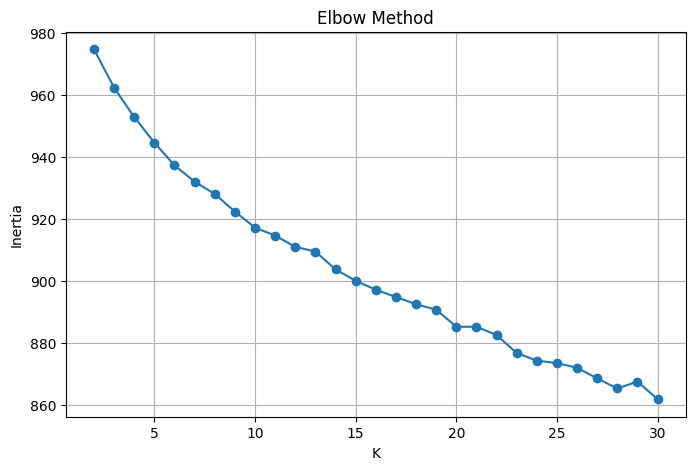

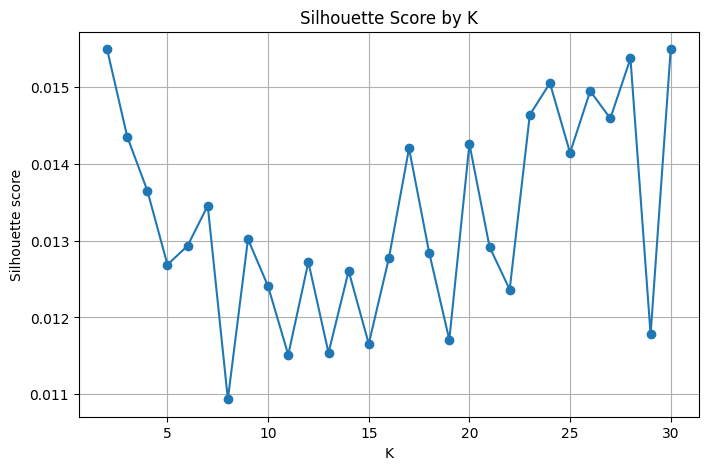

In [ ]:
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_values = range(2, 31)

inertias = []
silhouette_scores = []

tqdm.write("Step 5/6 - Computing KMeans metrics...")

X_sample = X_combined[:1000]

for k in tqdm(K_values):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, labels))

tqdm.write("Step 6/6 - Plotting results...")

plt.figure(figsize=(8, 5))
plt.plot(K_values, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_values, silhouette_scores, marker="o")
plt.title("Silhouette Score by K")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()



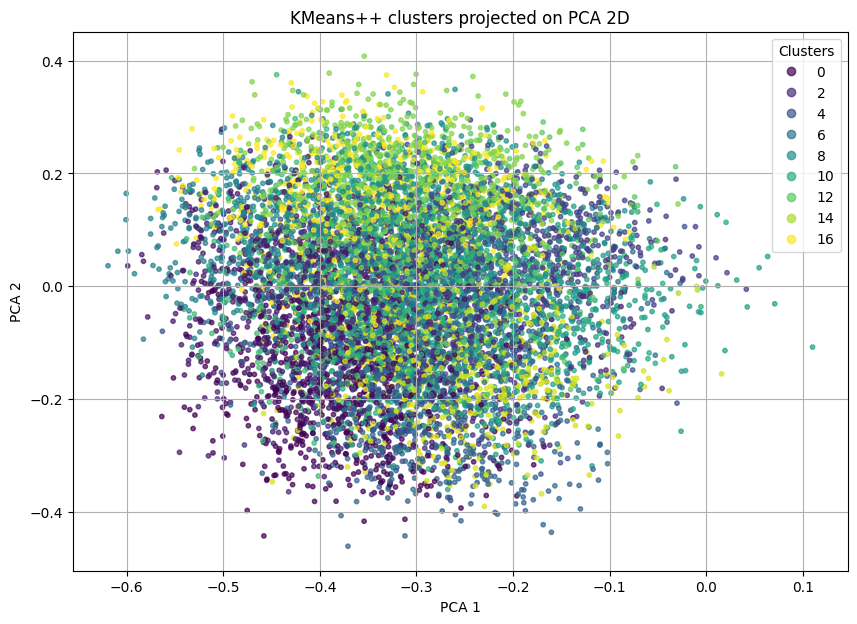


CLUSTER 0 | size = 596 | score = 0.0205
- I walked in on my parents having sex last night... Possibly the most awkward 45 minutes of my life...
- I saw a woman texting and driving today and it really pissed me off... So I rolled down my window and threw my beer at her.
- I saw a girl texting and driving earlier today and it really pissed me off... So I rolled my window down and threw my beer at her.
- Got in a fight with the wife so I didn't let her sleep on the couch with me last night.
- Accidentally ran over my neighbor's cat today and I was scared to tell him to his face so I left a note saying "Curiosity was here"
- So I brought a girl home from the bar last night... When we got to bed, she said "Give me twelve inches and make me bleed!" So I fucked her twice and punched her in the face.
- I was makin out with a cute girl but it got ruined when she ran her hand up my leg and squeezed all the spaghetti out of my pocket
- My wife wanted to have sex in the back of the car..... So I 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_samples

K = 17

# 1) KMeans++
kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X_combined)
df_sample["cluster"] = labels

# 2) Projection 2D type PCA
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_combined)

df_sample["PCA1"] = X_2d[:, 0]
df_sample["PCA2"] = X_2d[:, 1]

# 3) Affichage
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_sample["PCA1"],
    df_sample["PCA2"],
    c=df_sample["cluster"],
    s=10,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans++ clusters projected on PCA 2D")
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# 4) Blagues les plus proches des centroïdes
distances_to_centroids = kmeans.transform(X_combined)


# score silhouette pour chaque point
sample_silhouette_values = silhouette_samples(X_combined, labels)

for cluster_id in range(K):
    cluster_indices = np.where(labels == cluster_id)[0]

    # score moyen du cluster
    cluster_score = sample_silhouette_values[cluster_indices].mean()

    cluster_distances = distances_to_centroids[cluster_indices, cluster_id]
    sorted_local_indices = np.argsort(cluster_distances)

    top_n = 10
    closest_indices = cluster_indices[sorted_local_indices[:top_n]]

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id} | size = {len(cluster_indices)} | score = {cluster_score:.4f}")

    for idx in closest_indices:
        print("-", df_sample.iloc[idx]["Joke"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_top_terms_per_cluster(df, text_col="Joke", cluster_col="cluster", top_k=10):
    # 1. Construire un "document" par cluster
    cluster_ids = sorted(df[cluster_col].unique())
    cluster_docs = []

    for c in cluster_ids:
        texts = df[df[cluster_col] == c][text_col].tolist()
        cluster_docs.append(" ".join(texts))

    # 2. TF-IDF sur les clusters
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),     # mots + bigrammes
        max_features=10000,
        min_df=2                # ignore mots trop rares
    )

    X = vectorizer.fit_transform(cluster_docs)
    feature_names = np.array(vectorizer.get_feature_names_out())

    # 3. Extraire les top mots
    cluster_top_terms = {}

    for i, c in enumerate(cluster_ids):
        row = X[i].toarray().ravel()

        top_idx = row.argsort()[-top_k:][::-1]
        top_terms = feature_names[top_idx]

        cluster_top_terms[c] = list(top_terms)

    return cluster_top_terms

cluster_terms = get_top_terms_per_cluster(df)

for c, terms in cluster_terms.items():
    print(f"Cluster {c}: {terms}")

KeyError: 'joke'

### 2.4. Classification




1.   Labelisation des données avec les clusters extraits
2.   modèle de classification
3.   optimisation des paramètres
4.   entrainement du modèle



In [ ]:
class JokeDataset(Dataset):
    def __init__(self, df, embedding_col="embedding", label_col="label"):
        self.df = df.copy()
        self.embedding_col = embedding_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        joke = torch.tensor(
            self.df.iloc[idx][self.embedding_col],
            dtype=torch.float32,
            requires_grad=False
        )
        label = torch.tensor(self.df.iloc[idx][self.label_col], dtype=torch.long)
        return joke, label

class JokeDataModule(LightningDataModule):
    def __init__(self, df, embedding_col="embedding", label_col="label"):
        super().__init__()
        self.df = df.copy()
        self.embedding_col = embedding_col
        self.label_col = label_col
        self.scaler = None

    def prepare_data(self):
        embeddings = self.df[self.embedding_col].values.reshape(-1, 1)
        self.scaler = StandardScaler()
        scaled_embeddings = self.scaler.fit_transform(embeddings)

        self.df[self.embedding_col] = scaled_embeddings.tolist()

    def setup(self, stage=None):
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            self.df[self.embedding_col],
            self.df[self.label_col],
            test_size=0.2,
            random_state=42)

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.125,
            random_state=42)

        self.train_df = pd.DataFrame({
            'embedding': X_train.tolist(),
            'label': y_train.tolist()})

        self.val_df = pd.DataFrame({
            'embedding': X_val.tolist(),
            'label': y_val.tolist()})

        self.test_df = pd.DataFrame({
            'embedding': X_test.tolist(),
            'label': y_test.tolist()})

    def train_dataloader(self):
        return DataLoader(
            JokeDataset(self.train_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=True)

    def val_dataloader(self):
        return DataLoader(
            JokeDataset(self.val_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=False)

    def test_dataloader(self):
        return DataLoader(
            JokeDataset(self.test_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=False)

In [ ]:
class NNClassifier(L.LightningModule):
    def __init__(self, input_dim, num_classes, n_layers, n_units, learning_rate):
        super().__init__()

        self.save_hyperparameters()

        self.lr = learning_rate

        self.activation_fn = nn.ReLu()

        self.layers = nn.Sequential()
        self.layers.add_module('input_layer', nn.Linear(input_dim, n_units))
        self.layers.add_module('input_activation', self.activation_fn)
        for i in range(n_layers - 1):
            self.layers.add_module(f'hidden_layer_{i+1}', nn.Linear(n_units, n_units))
            self.layers.add_module(f'hidden_activation_{i+1}', self.activation_fn)
        self.out = nn.Linear(n_units, num_classes)

        self.criterion = nn.CrossEntropyLoss()

        self.optimizer = torch.optim.Adam

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.train_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.train_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.val_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')



    def forward(self, x):
        x = self.layers(x)
        x = self.out(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.train_acc(y_hat.argmax(dim=1), y)
            precision = self.train_precision(y_hat.argmax(dim=1), y)
            recall = self.train_recall(y_hat.argmax(dim=1), y)
            f1 = self.train_f1(y_hat.argmax(dim=1), y)

            self.log("train_loss", loss, prog_bar=True)
            self.log("train_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.val_acc(y_hat.argmax(dim=1), y)
            precision = self.val_precision(y_hat.argmax(dim=1), y)
            recall = self.val_recall(y_hat.argmax(dim=1), y)
            f1 = self.val_f1(y_hat.argmax(dim=1), y)

            self.log("val_loss", loss, prog_bar=True)
            self.log("val_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.test_acc(y_hat.argmax(dim=1), y)
            precision = self.test_precision(y_hat.argmax(dim=1), y)
            recall = self.test_recall(y_hat.argmax(dim=1), y)
            f1 = self.test_f1(y_hat.argmax(dim=1), y)

            self.log("test_loss", loss, prog_bar=True)
            self.log("test_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer =  self.optimizer(self.parameters(), lr=self.lr)
        return optimizer

In [ ]:
def objective(trial):
        n_layer = trial.suggest_int('n_layer', 1, 5)
        n_units = trial.suggest_categorical('n_units', [16, 32, 64, 128, 256, 512])
        learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

        model = NNClassifier(input_dim=?, num_classes=?, n_layers=n_layers, n_units=n_units, learning_rate=learning_rate)
        dm = JokeDataModule(df=?)

        logger = TensorBoardLogger(f"tb_log", name=f"trial_{trial.number}")

        pruning_callback = PyTorchLightningPruningCallback(
            trial, monitor="val_loss"
        )

        trainer = L.Trainer(
            max_epochs=1000,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5), pruning_callback],
            logger=logger,
            enable_checkpointing=False
        )

        trainer.fit(model, dm)
        val_result = trainer.validate(model, datamodule=dm)
        val_acc = val_result[0]['val_acc']
        trainer.test(model, datamodule=dm)

        return val_acc

In [ ]:
study = optuna.create_study(
    direction='maximize',
    storage='sqlite:///study.db',
    study_name='NNClassifier',
    load_if_exists=True)

study.optimize(objective, n_trials=100)

## 3. Results

Résultats du clustering, quels types de blagues ressortent ?
Performances de la classification

### 3.1 Clustering

Résultats du clustering, quels types de blagues ressortent ?

### 3.2. Classification

Performance du modèle de classification

## 4. Discussion

La conclusion plus ou moins

## 5. Future works

Perspectives futures

## References

1.   Abhinav Moudgil. **Short Jokes**. https://www.kaggle.com/datasets/abhinavmoudgil95/short-jokes
2.   Nils Reimers, Iryna Gurevych. **Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks**. Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing, 2019. https://arxiv.org/abs/1908.10084
3.   Alina Petukhovaa, João P. Matos-Carvalhoa, Nuno Fachada. **Text clustering with LLM embeddings**. International Journal of Cognitive Computing in Engineering, Volume 6, 2025. https://doi.org/10.1016/j.ijcce.2024.11.004

